<a href="https://colab.research.google.com/github/UW-CTRL/lmc-exercises/blob/main/exercises/02_unconstrained_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unconstrained optimization

Unconstrained optimization is concerned with finding the minimum or maximum of a function without any constraints on the variables.
This is a fundamental task in many areas of machine learning, statistics, engineering, and applied mathematics.
In this notebook, we will explore different techniques for solving unconstrained optimization problem by considering several standard test problems, such as the Rosenbrock function, to demonstrate optimization algorithms and their behavior.



In [1]:
from typing import Callable
import jax.numpy as jnp
import matplotlib.pyplot as plt
import functools
import jax
import equinox as eqx



## 1. Rosenbrock function


The Rosenbrock function is a classic test problem for optimization algorithms. It is defined as:

$$
f(x, y) = (a - x)^2 + b(y - x^2)^2
$$

where typically \( a = 1 \) and \( b = 100 \).

In [2]:
@jax.jit
def rosenbrock_func(x, a=1.0, b=100.0):
    return (a - x[0]) ** 2 + b * (x[1] - x[0] ** 2) ** 2

Let's visualize the function over the domain $[-2, 2] \times [-2, 2]$.


Text(0, 0.5, 'y')

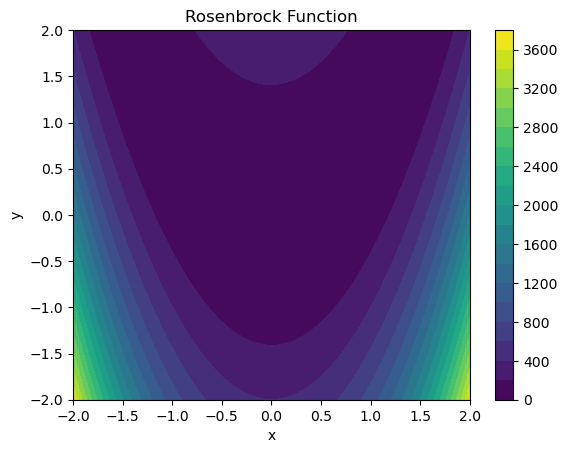

In [3]:
N = 100
lim = 2
X, Y = jnp.meshgrid(jnp.linspace(-lim, lim, N), jnp.linspace(-lim, lim, N))
XY = jnp.stack([X, Y], axis=-1).reshape(-1, 2)
Z = jax.vmap(rosenbrock_func)(XY).reshape([N, N])

plt.contourf(X, Y, Z, levels=20, cmap="viridis")
plt.colorbar()
plt.title("Rosenbrock Function")
plt.xlabel("x")
plt.ylabel("y")


### Gradient Descent Optimization

In this part, you will implement gradient descent to locate the minimum of the Rosenbrock function, starting from an initial guess.

Write a function called `gradient_descent` that takes as input:
- A function to minimize,
- An initial guess,
- A learning rate (step size),
- And the number of iterations.

Your function should iteratively update the guess by stepping in the direction of the negative gradient, and return the optimization trajectory and final solution.


In [21]:
def gradient_descent(
    func: Callable[[jnp.ndarray, jnp.ndarray], jnp.ndarray],
    guess: jnp.ndarray,
    learning_rate: float = 0.001,
    num_steps: int = 10000,
):
    """
    Perform gradient descent to find the minimum of the Rosenbrock function.
    Args:
        func: The function to minimize.
        guess: The initial guess.
        learning_rate: The learning rate (step size).
        num_steps: The number of iterations.
    Returns:
        guesses: The list of guesses.
        values: The list of function values.
        sol: The final guess.
    """

    gradient_func = jax.grad(func)
    def grad_step(x, _):
        x_next = x - learning_rate * gradient_func(x)
        return x_next, (x_next, func(x_next))

    sol, (guesses, values) = jax.lax.scan(grad_step, guess, xs=None, length=num_steps)

    return guesses, values, sol


    ###### end of add your code here
    
def slow_gradient_descent(
    func: Callable[[jnp.ndarray, jnp.ndarray], jnp.ndarray],
    initial_guess: jnp.ndarray,
    learning_rate: float = 0.001,
    num_steps: int = 10000,
):
    """
    Perform gradient descent to find the minimum of the Rosenbrock function.
    Args:
        func: The function to minimize.
        initial_guess: The initial guess.
        learning_rate: The learning rate (step size).
        num_steps: The number of iterations.
    Returns:
        guesses: The list of guesses.
        values: The list of function values.
        sol: The final guess.
    """
    # TODO: implement gradient descent
    ### add your code here
    gradient_func = jax.grad(func, 0)
    guesses = jnp.array([initial_guess])
    values = jnp.array([func(initial_guess)])
    guess = initial_guess
    for i in range(num_steps):
        guess = guess - learning_rate * gradient_func(guess)
        jnp.append(guesses, guess)
        jnp.append(values, func(guess))
        
        # # debug print:
        # if i % 200 == 0:
        #     print(f"iteration: {i}\tguess (x,y): {guess}\tvalue: {func(guess)}")

    final_guess = guess

    return guesses, values, final_guess



Run your `gradient_descent` function and plot the results.

In [22]:
guesses, values, sol = slow_gradient_descent(
    rosenbrock_func, jnp.array([-0.75, -0.75]), learning_rate=0.01, num_steps=10000
)

In [27]:
%timeit guesses, values, sol = gradient_descent(rosenbrock_func, jnp.array([-0.75, -0.75]), learning_rate=0.01, num_steps=1000)

96.4 ms ± 13.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


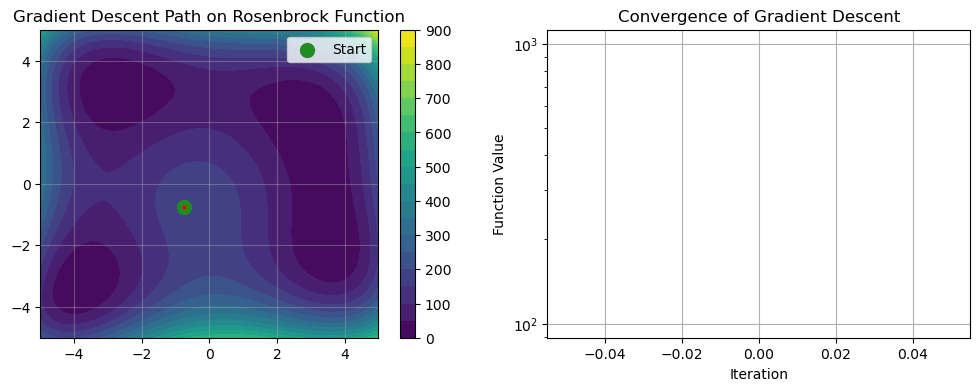

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.contourf(X, Y, Z, levels=20, cmap="viridis")
plt.colorbar()
plt.plot(
    guesses[:, 0], guesses[:, 1], marker="o", color="red", markersize=2, linewidth=1
)
plt.scatter(guesses[:1, 0], guesses[:1, 1], color="forestgreen", label="Start", s=100)
plt.grid(alpha=0.4)
plt.title("Gradient Descent Path on Rosenbrock Function")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(values)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Function Value")
plt.title("Convergence of Gradient Descent")
plt.grid()


## 2. Himmelblau’s function

Himmelblau’s function is a well-known test function for optimization algorithms, particularly in two dimensions. It is defined as:

$$
f(x, y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2
$$

This function is notable for having multiple local minima and saddle points, making it a challenging landscape for optimization methods. The global minima are located at four points in the $(x, y)$ plane:

- $(3.0, 2.0)$
- $(-2.805, 3.131)$
- $(-3.779, -3.283)$
- $(3.584, -1.848)$

At each of these points, the function value is zero: $f(x, y) = 0$. The complex topology of Himmelblau’s function makes it useful for evaluating the performance and robustness of optimization algorithms.

Text(0, 0.5, 'y')

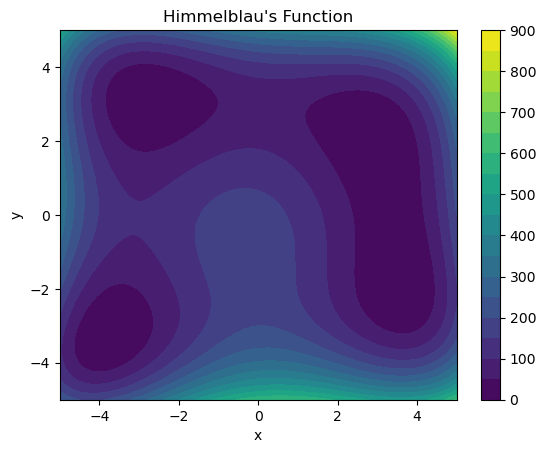

In [29]:
@jax.jit
def himmelblau_func(x):
    return (x[0] ** 2 + x[1] - 11) ** 2 + (x[0] + x[1] ** 2 - 7) ** 2


# visualize the function
N = 100
lim = 5
X, Y = jnp.meshgrid(jnp.linspace(-lim, lim, N), jnp.linspace(-lim, lim, N))
XY = jnp.stack([X, Y], axis=-1).reshape(-1, 2)
Z = jax.vmap(himmelblau_func)(XY).reshape([N, N])

plt.contourf(X, Y, Z, levels=20, cmap="viridis")
plt.colorbar()
plt.title("Himmelblau's Function")
plt.xlabel("x")
plt.ylabel("y")


### (a) Perform gradient descent
Using your `gradient_descent` function you created previously, perform gradient descent on `himmelblau_func`

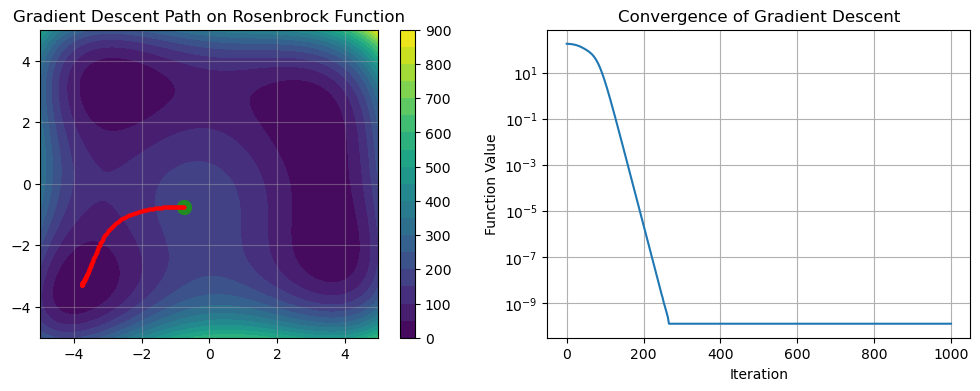

In [9]:
# try each one of the initial guesses below
# guess = jnp.array([-0.75, 0.75])
guess = jnp.array([-0.75, -0.75])
# guess = jnp.array([0.75, 0.75])
# guess = jnp.array([0.75, -0.75])


guesses, values, sol = gradient_descent(
    himmelblau_func, guess, learning_rate=0.001, num_steps=1000
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.contourf(X, Y, Z, levels=20, cmap="viridis")
plt.colorbar()
plt.plot(
    guesses[:, 0], guesses[:, 1], marker="o", color="red", markersize=2, linewidth=1
)
plt.scatter(guesses[:1, 0], guesses[:1, 1], color="forestgreen", label="Start", s=100)

plt.grid(alpha=0.4)
plt.title("Gradient Descent Path on Rosenbrock Function")

plt.subplot(1, 2, 2)
plt.plot(values)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Function Value")
plt.title("Convergence of Gradient Descent")
plt.grid()


### (c) Using `jax.vmap` to perform gradient descent with multiple initial guesses

Here, you will find the function `functools.partial` useful. You can define a function with its some of its arguments fixed.  

In [10]:
# construct multiple initial guesses
key = jax.random.PRNGKey(0)
n_samples = 1000
# choose one of the following below
guess = jax.random.uniform(key, (n_samples, 2), minval=-5, maxval=5) # random initial guesses
guess = jnp.array([[-0.75, 0.75], [-0.75, -0.75], [0.75, 0.75], [0.75, -0.75]]) # fixed initial guesses

# define the gradient descent function with fixed arguments
gd_func = functools.partial(gradient_descent, learning_rate=0.001, num_steps=1000)

# perform gradient descent for each initial guess using jax.vmap
guesses, values, sol = jax.vmap(gd_func, in_axes=[None, 0])(himmelblau_func, guess)

Plot the results

Text(0.5, 1.0, 'Gradient Descent Path on Himmelblau Function')

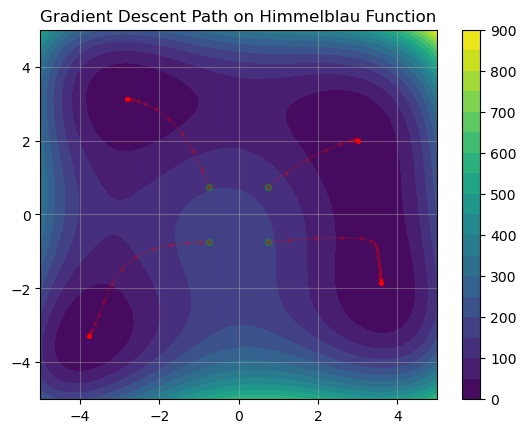

In [11]:
# plot the results
plt.contourf(X, Y, Z, levels=20, cmap="viridis")
plt.colorbar()
[
    plt.plot(
        g[::10, 0],
        g[::10, 1],
        marker="o",
        color="red",
        alpha=0.2,
        markersize=2,
        linewidth=1,
    )
    for g in guesses
]
[plt.scatter(g[:1, 0], g[:1, 1], color="forestgreen", alpha=0.5, s=20) for g in guesses]


plt.grid(alpha=0.4)
plt.title("Gradient Descent Path on Himmelblau Function")
